In [1]:
import numpy as np
import sympy as sp
import itertools
from jetgp.wddegp.wddegp import wddegp
import jetgp.utils as utils
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 12})

n_order = 2
n_bases = 2
num_pts_per_axis = 5
test_grid_resolution = 10
domain_bounds = ((-1, 1), (-1, 1))
kernel = "SE"
kernel_type = "anisotropic"
normalize_data = True
np.random.seed(0)

x1_sym, x2_sym = sp.symbols('x1 x2')
f_sym = ((4 - 2.1*x1_sym**2 + (x1_sym**4)/3.0) * x1_sym**2 +
        x1_sym*x2_sym + (-4 + 4*x2_sym**2) * x2_sym**2)
grad_x1_sym = sp.diff(f_sym, x1_sym)
grad_x2_sym = sp.diff(f_sym, x2_sym)

true_function_np = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1_sym, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2_sym, 'numpy')

def true_function(X):
    return true_function_np(X[:, 0], X[:, 1])

def true_gradient(x1, x2):
    return grad_x1_func(x1, x2), grad_x2_func(x1, x2)

submodel_groups_initial = [
    [1, 2, 3], [5, 10, 15], [9, 14, 19], [21, 22, 23],
    [0], [4], [20], [24], [6, 7, 8, 11, 12, 13, 16, 17, 18]
]

submodel_ray_thetas = [
    [-np.pi/4, 0, np.pi/4], [-np.pi/4, 0, np.pi/4],
    [-np.pi/4, 0, np.pi/4], [-np.pi/4, 0, np.pi/4],
    [-np.pi/2, 0, -np.pi/4], [np.pi/2, 0, np.pi/4],
    [np.pi/2, 0, np.pi/4], [-np.pi/2, 0, -np.pi/4],
    [np.pi/2, np.pi/4, np.pi/4 + np.pi/2]
]

submodel_der_indices = [
    [[[[1,1]], [[1,2]], [[2,1]], [[2,2]], [[3,1]], [[3,2]]]]
    for _ in range(len(submodel_groups_initial))
]

x_lin = np.linspace(-1, 1, 5)
y_lin = np.linspace(-1, 1, 5)
X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
X_train_initial = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
reorder_indices = list(itertools.chain.from_iterable(submodel_groups_initial))
X_train = X_train_initial[reorder_indices]

submodel_indices = []
current_pos = 0
for group in submodel_groups_initial:
    submodel_indices.append(list(range(current_pos, current_pos + len(group))))
    current_pos += len(group)

y_train_data_all = []
rays_data_all = []
y_func_values = true_function(X_train).reshape(-1, 1)

for k, group_indices in enumerate(submodel_indices):
    X_sub = X_train[group_indices]
    thetas = submodel_ray_thetas[k]
    rays = np.column_stack([[np.cos(t), np.sin(t)] for t in thetas])
    for i in range(rays.shape[1]):
        rays[:, i] = rays[:, i] / np.linalg.norm(rays[:, i])
    rays_data_all.append(rays)
    y_train_submodel = [y_func_values]

    for ray_idx, ray in enumerate(rays.T):
        for order in range(1, n_order + 1):
            deriv_values = []
            for point in X_sub:
                x1, x2 = point[0], point[1]
                gx1, gx2 = true_gradient(x1, x2)
                if order == 1:
                    d_ray = gx1 * ray[0] + gx2 * ray[1]
                    deriv_values.append(d_ray)
                elif order == 2:
                    h11 = sp.diff(grad_x1_sym, x1_sym)
                    h12 = sp.diff(grad_x1_sym, x2_sym)
                    h22 = sp.diff(grad_x2_sym, x2_sym)
                    hessian_funcs = {
                        'h11': sp.lambdify([x1_sym, x2_sym], h11, 'numpy'),
                        'h12': sp.lambdify([x1_sym, x2_sym], h12, 'numpy'),
                        'h22': sp.lambdify([x1_sym, x2_sym], h22, 'numpy')
                    }
                    h11_val = hessian_funcs['h11'](x1, x2)
                    h12_val = hessian_funcs['h12'](x1, x2)
                    h22_val = hessian_funcs['h22'](x1, x2)
                    d2_ray = (ray[0]**2 * h11_val +
                             2 * ray[0] * ray[1] * h12_val +
                             ray[1]**2 * h22_val)
                    deriv_values.append(d2_ray)
            y_train_submodel.append(np.array(deriv_values).reshape(-1, 1))
    y_train_data_all.append(y_train_submodel)

gp_model = wddegp(X_train, y_train_data_all, n_order, n_bases,
                  submodel_indices, submodel_der_indices, rays_data_all,
                  normalize=normalize_data, kernel=kernel, kernel_type=kernel_type)
params = gp_model.optimize_hyperparameters(optimizer='jade', pop_size=10,
                                            n_generations=5, debug=False)

x_test_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
y_test_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(x_test_lin, y_test_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

y_pred, submodel_vals = gp_model.predict(X_test, params, calc_cov=False, return_submodels=True)
y_true = true_function(X_test)

print("Data ready, now testing plotting...")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Data ready, now testing plotting...


Test 1: Creating figure (THIS MIGHT HANG)...
Figure created successfully!


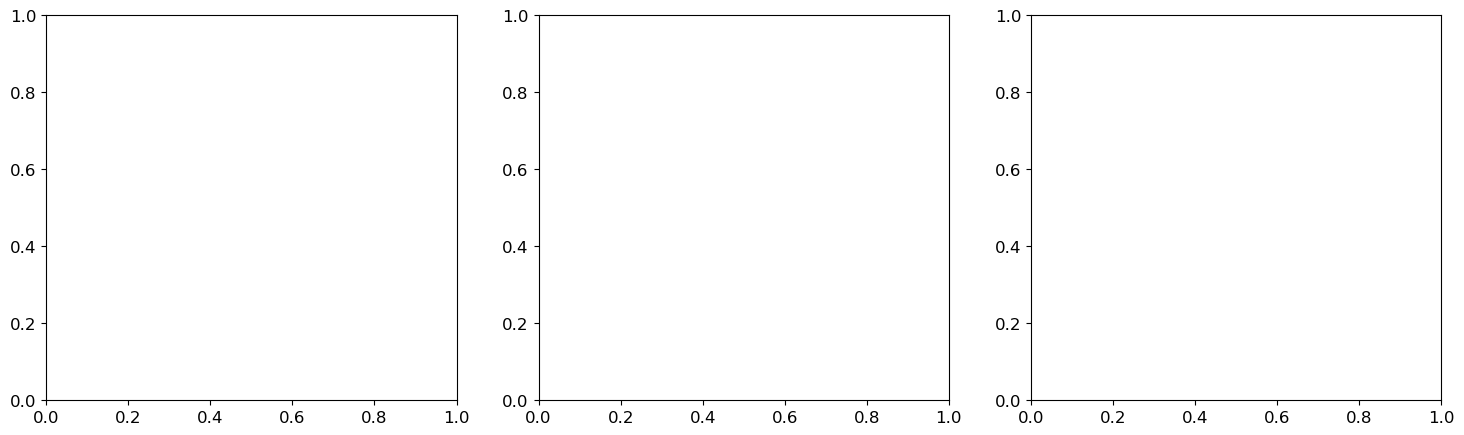

In [2]:
print("Test 1: Creating figure (THIS MIGHT HANG)...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
print("Figure created successfully!")

In [3]:
print("Test 2: Preparing data for plotting...")
y_pred_grid = y_pred.reshape(X1_grid.shape)
y_true_grid = y_true.reshape(X1_grid.shape)
abs_error = np.abs(y_true - y_pred).reshape(X1_grid.shape)
print("Data reshaped successfully!")

Test 2: Preparing data for plotting...
Data reshaped successfully!


In [4]:
print("Test 3: First contourf (THIS MIGHT HANG)...")
c1 = axes[0].contourf(X1_grid, X2_grid, y_pred_grid, levels=50, cmap="viridis")
print("First contour done!")

Test 3: First contourf (THIS MIGHT HANG)...
First contour done!


In [5]:
print("Test 4: Scatter plot (THIS MIGHT HANG)...")
axes[0].scatter(X_train[:, 0], X_train[:, 1], c="red", edgecolor="k", s=50, zorder=5)
print("Scatter done!")

Test 4: Scatter plot (THIS MIGHT HANG)...
Scatter done!


In [6]:
print("Test 5: Colorbar (THIS MIGHT HANG)...")
fig.colorbar(c1, ax=axes[0])
print("Colorbar done!")

Test 5: Colorbar (THIS MIGHT HANG)...
Colorbar done!


In [7]:
print("Test 6: plt.show() (THIS MIGHT HANG)...")
plt.show()
print("Show complete!")

Test 6: plt.show() (THIS MIGHT HANG)...
Show complete!
